# [Tools이란?](https://docs.langchain.com/oss/python/langchain/tools)
- LLM이 실행할 수 있는 구체적인 기능을 정의한 것.
- 예: 웹 검색, DB 질의, API 호출, 계산기 등

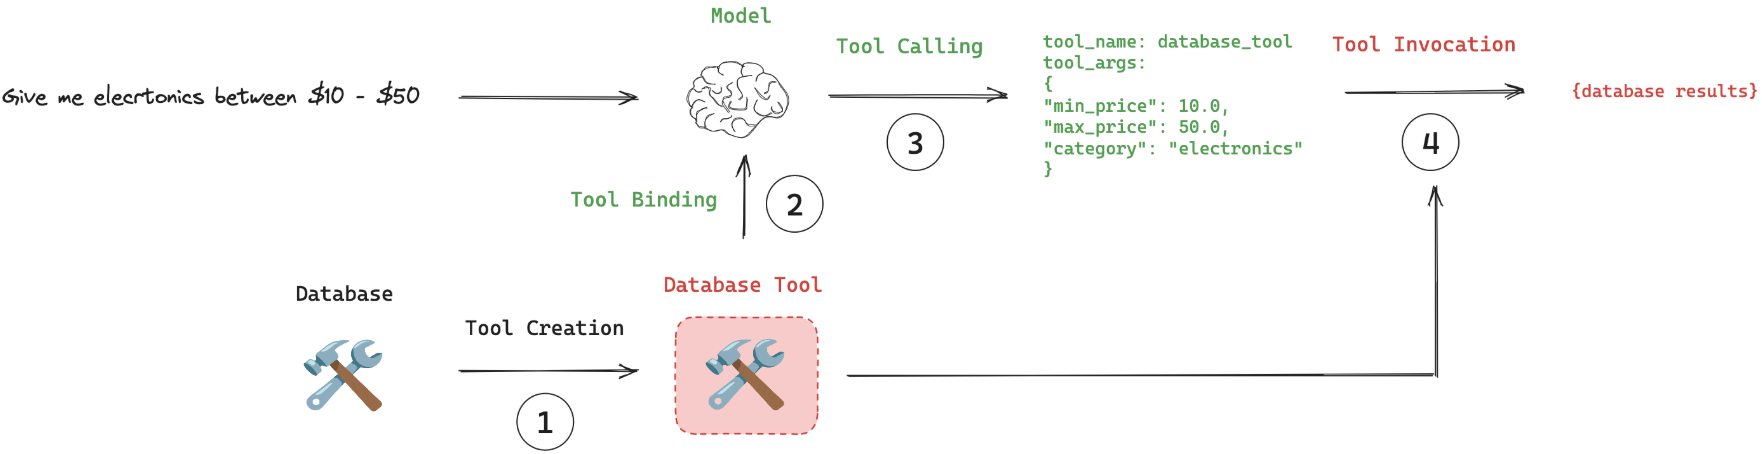

1. `도구 생성`: @tool 데코레이터를 사용하여 도구를 생성합니다 . 도구는 함수와 해당 스키마 간의 연결입니다.
2. `도구 바인딩`: 도구는 도구 호출을 지원하는 모델에 연결되어야 합니다. 이를 통해 모델이 도구와 도구에 필요한 관련 입력 스키마를 인식할 수 있습니다.
3. `도구 호출`: 적절한 경우 모델은 도구를 호출하고 해당 응답이 도구의 입력 스키마에 부합하는지 확인할 수 있습니다.
4. `도구 실행`: 도구는 모델이 제공한 인수를 사용하여 실행될 수 있습니다.

# [Agents (에이전트)](https://docs.langchain.com/oss/python/langchain/agents)
- 여러 개의 Tools를 관리하고, 어떤 Tool을 어떤 순서로 사용할지 결정하는 역할을 담당합니다.

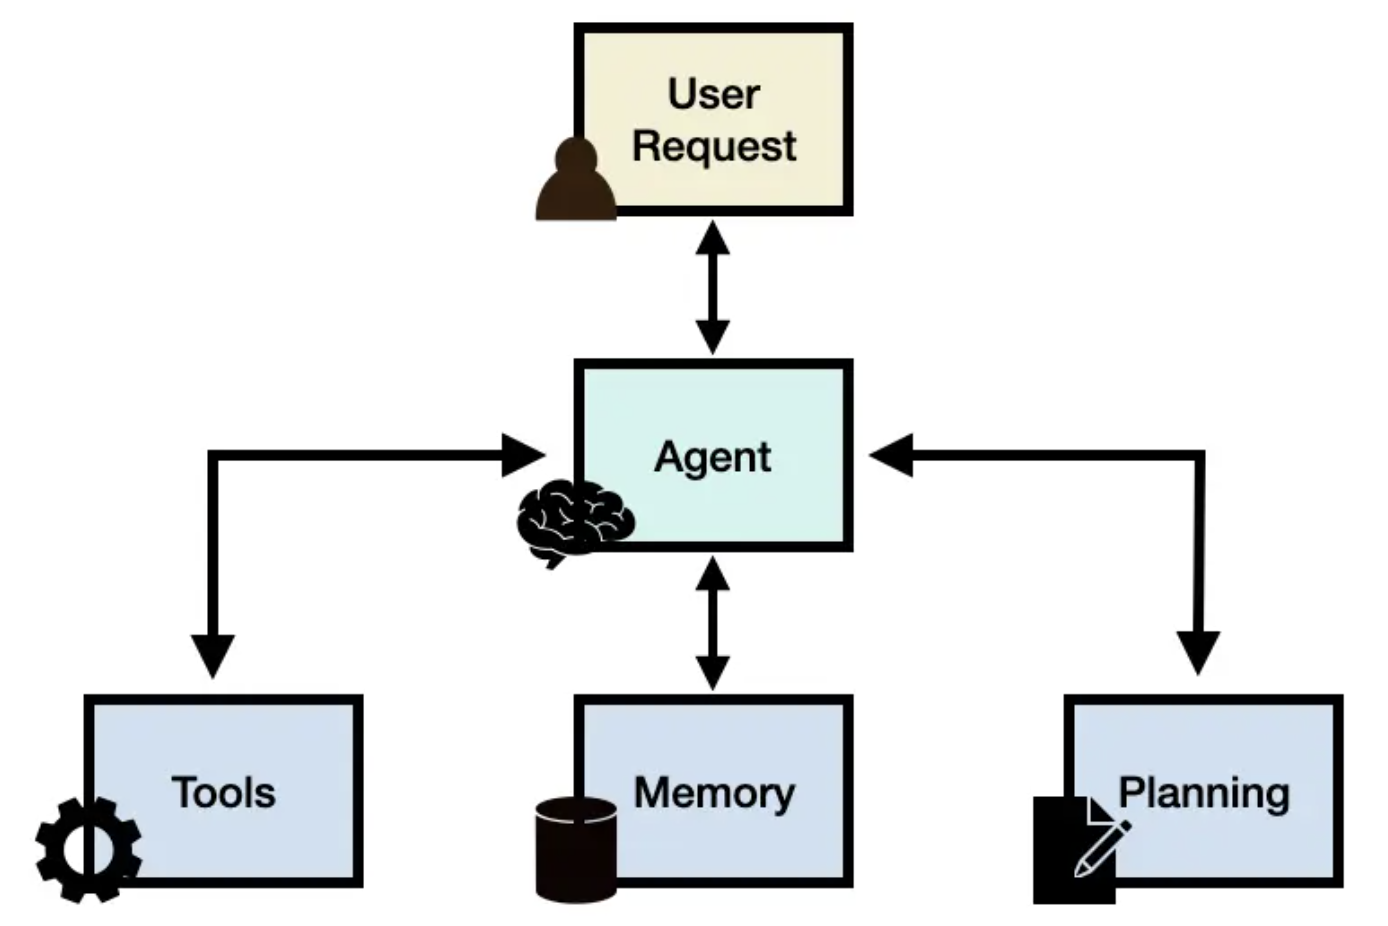

## Tools vs Agents
- Tools는 "LLM이 사용할 수 있는 도구"
- Agents는 "도구를 언제, 어떻게 사용할지 결정하는 지능"

## 단일 에이전트 vs 멀티 에이전트

### 단일 에이전트 (Single Agent)
```
사용자 → Agent → 도구들 → 응답
```
**장점:**
- 간단한 구조
- 빠른 응답
- 관리 용이

**단점:**
- 복잡한 작업 처리 어려움
- 전문화된 작업 처리 제한
- 컨텍스트 관리 복잡


### 멀티 에이전트 (Multi-Agent)
```
사용자 → 조정자 → Agent1 (전문가1)
              ↓
              → Agent2 (전문가2)
              ↓
              → Agent3 (전문가3)
```
**장점:**
- 각 에이전트가 특정 도메인 전문화
- 복잡한 워크플로우 처리
- 병렬 처리 가능

**단점:**
- 복잡한 오케스트레이션 필요
- 디버깅 어려움
- 오버헤드 증가


# Setup

API Key 발급 및 환경변수에 등록

## [OpenAI](https://openai.com/)
- OpenAI는 인공지능 기술을 연구하고 세상에 공개하는 회사입니다. 
- 우리가 쓰는 ChatGPT, 이미지 만드는 DALL·E 같은 것도 OpenAI가 만든 LLM 모델들입니다.

### [OpenAI 가입/로그인](https://platform.openai.com/docs/overview)

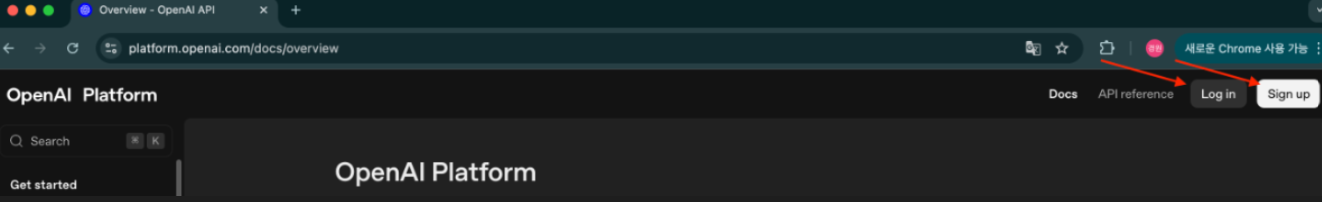

### [OpenAI 결제](https://platform.openai.com/settings/organization/billing/overview)

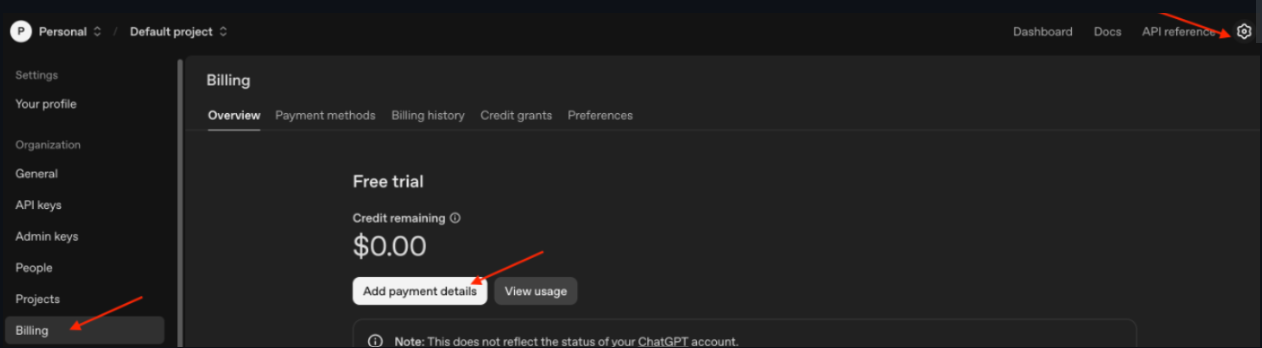

### [OpenAI API Key 발급](https://platform.openai.com/api-keys)

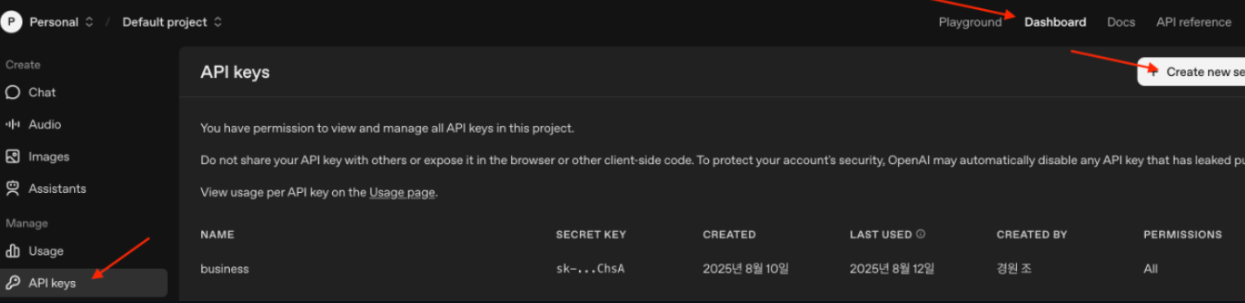

## [Langsmith](https://docs.langchain.com/langsmith/observability)
- langsmith는 langchain에서 만든 온라인 기반의 LLM 애플리케이션 모니터링, 테스트 지원, 배포 지원 도구이다.

### [Concepts](https://docs.smith.langchain.com/observability/concepts)
- 이 개념 가이드는 LangSmith에 추적 로그를 기록할 때 이해해야 할 중요한 주제를 다룹니다.
- Trace는 애플리케이션이 입력에서 출력으로 가는 일련의 단계를 의미합니다. 이 각각의 개별 단계는 Run으로 표현됩니다.
- Project는 단순히 여러 개의 Trace 모음입니다.

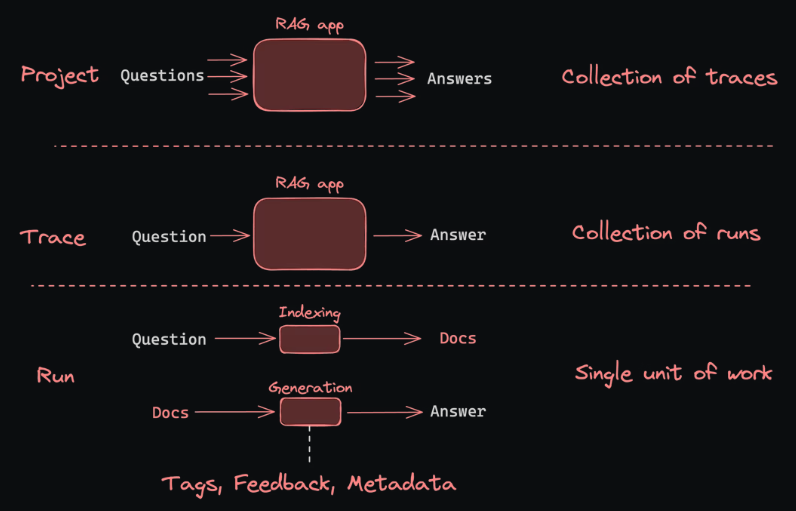

### [LangSmith 사이트](https://smith.langchain.com/)에 접속하여 회원가입

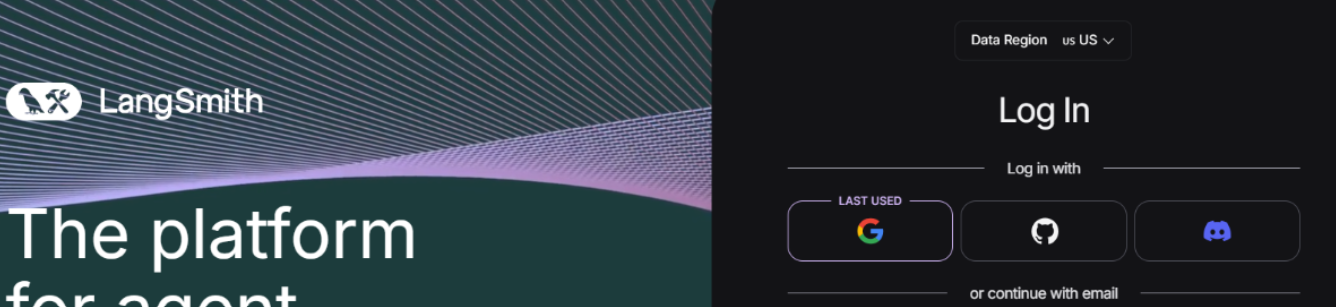

### [API Key 생성하기](https://smith.langchain.com/)

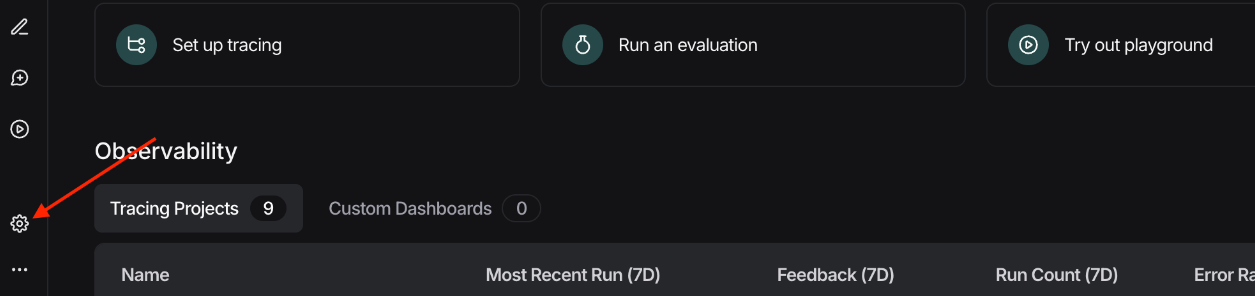

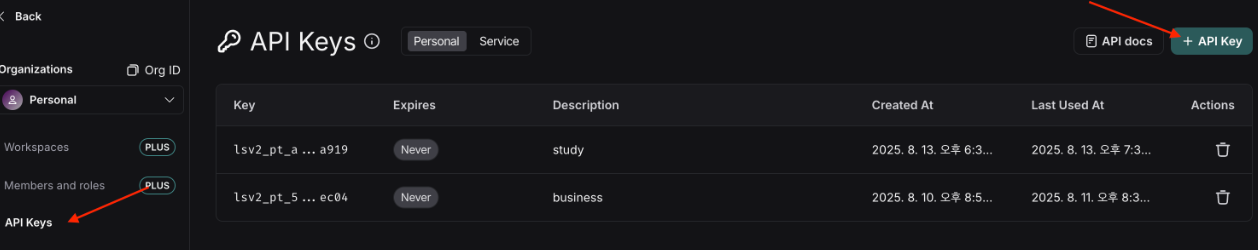

### Langsmith 설정
- `LANGCHAIN_TRACING_V2`: "true" 로 설정하면 추적을 시작합니다.
- `LANGCHAIN_ENDPOINT`: https://api.smith.langchain.com 변경하지 않습니다.
- `LANGCHAIN_API_KEY`: 이전 단계에서 발급받은 키 를 입력합니다.
- `LANGCHAIN_PROJECT`: 프로젝트 명 을 기입하면 해당 프로젝트 그룹으로 모든 실행(Run) 이 추적됩니다.

## 환경변수 등록 

In [1]:
from dotenv import load_dotenv 

load_dotenv()

True

# 예제 

## 기본적인 Tool 생성 예제
- LangChain에서 Tool은 AI가 사용할 수 있는 기능을 의미합니다.
- 간단한 수학 계산 도구를 만들어보겠습니다.


### 1단계: 간단한 더하기 도구 만들기

In [2]:
from langchain_core.tools import tool

@tool
def add_numbers(a: float, b: float) -> float:
    """두 숫자를 더합니다."""
    return a + b

In [3]:
add_numbers.invoke({
  "a":5, "b":3
})

8.0

### 2단계: 곱하기 도구 만들기

In [4]:
def multiply_numbers(a: float, b: float) -> float:
    """두 숫자를 곱합니다."""
    return a * b

In [5]:
multiply_numbers(3,5)

15

In [6]:
from langchain_core.tools import StructuredTool

# StructuredTool은 함수 시그니처를 자동으로 분석합니다.
multiply_numbers_tool = StructuredTool.from_function(
    func=multiply_numbers,
    name="multiply_numbers",
    description="두 숫자는 모두 자연수이고, 이 두 숫자를 곱하는 함수입니다."
)

In [7]:
multiply_numbers_tool.invoke({
  "a":5, "b":3
})

15.0

### 3단계: 할 일 알림을 스케줄링

In [8]:
from pydantic import BaseModel, Field
from datetime import datetime, timedelta


class ReminderInput(BaseModel):
    task: str = Field(description="할 일 내용")
    hours_from_now: int = Field(description="현재부터 몇 시간 후에 알림할지")

# return_direct=True
# -> 도구 결과를 그대로 사용자에게 반환 (LLM 추론 없음)
@tool("new_schedule_reminder", args_schema=ReminderInput, return_direct=True)
def schedule_reminder(task: str, hours_from_now: int) -> str:
    """
    할 일 알림을 스케줄링하는 도구입니다.
    task: 할 일 내용입니다.
    hours_from_now: 현재부터 몇 시간 후에 알림할지입니다.
    """
    reminder_time = datetime.now() + timedelta(hours=hours_from_now)
    return f"알림 설정 완료: '{task}' - {reminder_time.strftime('%Y-%m-%d %H:%M')}에 알림됩니다."


In [9]:
schedule_reminder.invoke({
  "task":"Multi Agent 공부", "hours_from_now":3
})

"알림 설정 완료: 'Multi Agent 공부' - 2025-12-24 01:10에 알림됩니다."

### 4단계: 도구들을 리스트로 만들기

In [10]:
tools = [add_numbers, multiply_numbers_tool, schedule_reminder]

In [11]:
for tool in tools:
    print("=" * 50)
    print(f"Tool 이름: {tool.name}")
    print(f"Tool 설명: {tool.description}")
    print(f"Tool 인풋 파라미터: {tool.args}")
    print(f"Tool return_direct: {tool.return_direct}")

Tool 이름: add_numbers
Tool 설명: 두 숫자를 더합니다.
Tool 인풋 파라미터: {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}
Tool return_direct: False
Tool 이름: multiply_numbers
Tool 설명: 두 숫자는 모두 자연수이고, 이 두 숫자를 곱하는 함수입니다.
Tool 인풋 파라미터: {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}
Tool return_direct: False
Tool 이름: new_schedule_reminder
Tool 설명: 할 일 알림을 스케줄링하는 도구입니다.
task: 할 일 내용입니다.
hours_from_now: 현재부터 몇 시간 후에 알림할지입니다.
Tool 인풋 파라미터: {'task': {'description': '할 일 내용', 'title': 'Task', 'type': 'string'}, 'hours_from_now': {'description': '현재부터 몇 시간 후에 알림할지', 'title': 'Hours From Now', 'type': 'integer'}}
Tool return_direct: True


### 5단계: LLM 설정
- [OpenAI(ChatGPT) Model](https://platform.openai.com/docs/models)
- [모델별 금액](https://platform.openai.com/docs/pricing) 

In [12]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### 6단계: Agent 설정

In [13]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="""
    당신은 주어진 도구를 반드시 사용해서만 답변해야 하는 AI 어시스턴트입니다.
    절대로 자신의 지식으로 직접 답변하지 마세요.
    모든 최종 답변은 반드시 도구의 출력 결과를 기반으로 해야 합니다.
    """
)

#### Display

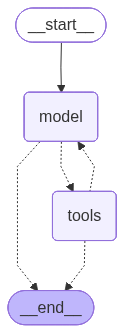

In [14]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

### 7단계: 실행 예제

> 콜백 핸들러 사용: StdOutCallbackHandler를 사용하면 에이전트의 실행 과정을 콘솔에 출력할 수 있습니다.

In [15]:
from langchain_core.callbacks import StdOutCallbackHandler

callbacks = [StdOutCallbackHandler()]

> 테스트 

In [16]:
from langchain_core.messages import HumanMessage

user_input = "3시간 후에 회의 준비하라고 알림 설정해줘"
result = agent.invoke(
    {"messages": HumanMessage(content=user_input)},
    config={"callbacks": callbacks}
)



> Entering new LangGraph chain...


> Entering new model chain...

> Finished chain.


> Entering new tools chain...
content="알림 설정 완료: '회의 준비' - 2025-12-24 01:15에 알림됩니다." name='new_schedule_reminder' tool_call_id='call_zcyod7h7yWq4PFBJzC8YWCl9'
> Finished chain.

> Finished chain.


In [17]:
print(result['messages'][-1].content)

알림 설정 완료: '회의 준비' - 2025-12-24 01:15에 알림됩니다.


In [18]:
from langchain_core.messages import HumanMessage

user_input = "5와 3을 더하고, 그 결과에 2를 곱해주세요."
result = agent.invoke(
    {"messages": HumanMessage(content=user_input)},
    config={"callbacks": callbacks}
)



> Entering new LangGraph chain...


> Entering new model chain...

> Finished chain.


> Entering new tools chain...
content='8.0' name='add_numbers' tool_call_id='call_9fNtra251xv2iZNxLLb5bnKl'
> Finished chain.


> Entering new model chain...

> Finished chain.


> Entering new tools chain...
content='16.0' name='multiply_numbers' tool_call_id='call_LWzuAC2WMBJbuRpSPMKpsT9d'
> Finished chain.


> Entering new model chain...

> Finished chain.

> Finished chain.


In [19]:
print(result['messages'][-1].content)

결과: 16.0 입니다.

계산 요약: 5 + 3 = 8, 8 × 2 = 16.0


## [Langsmith에서 확인하기](https://smith.langchain.com/)

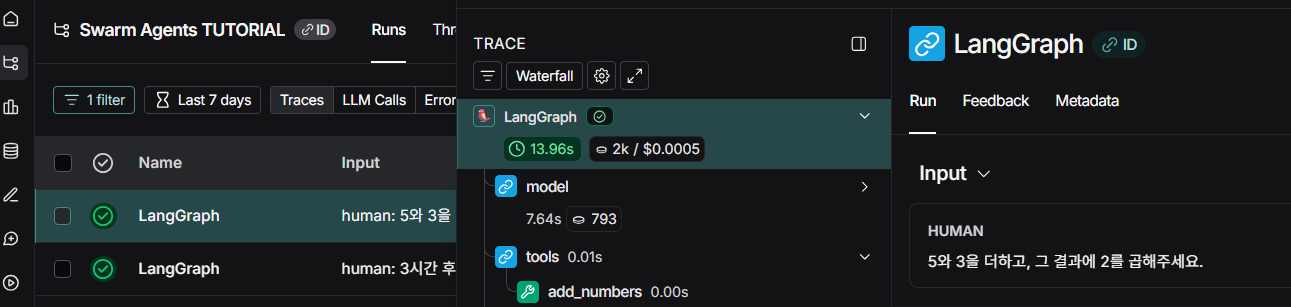